# ЭТАП 1. ПОДГОТОВКА ДАННЫХ

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
# Dataset:
# https://www.kaggle.com/datasets/shrutimechlearn/churn-modelling/data


pd.set_option('display.max_columns', None)

df = pd.read_csv('../data/raw/Churn_Modelling.csv')


print('\nПервые 5 строк датасета:\n')

df.head()


Первые 5 строк датасета:



,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [3]:
print(df['CreditScore'].min())
print(df['CreditScore'].max())

350
850


# ИЗУЧЕНИЕ СТРУКТУРЫ ДАННЫХ

In [4]:
# Размер датасета

print('Размер датасета:')
print(df.shape)

# Информация о данных

print('\nИнформация о датасете:')
df.info()

Размер датасета:
(10000, 14)

Информация о датасете:
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.2 MB


# ПРОВЕРКА ТИПОВ ПРИЗНАКОВ

In [5]:
print('Типы данных:\n')

print(df.dtypes)

Типы данных:

RowNumber            int64
CustomerId           int64
Surname                str
CreditScore          int64
Geography              str
Gender                 str
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object


# ПРОВЕРКА ПРОПУЩЕННЫХ ЗНАЧЕНИЙ

Количество пропущенных значений:

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64


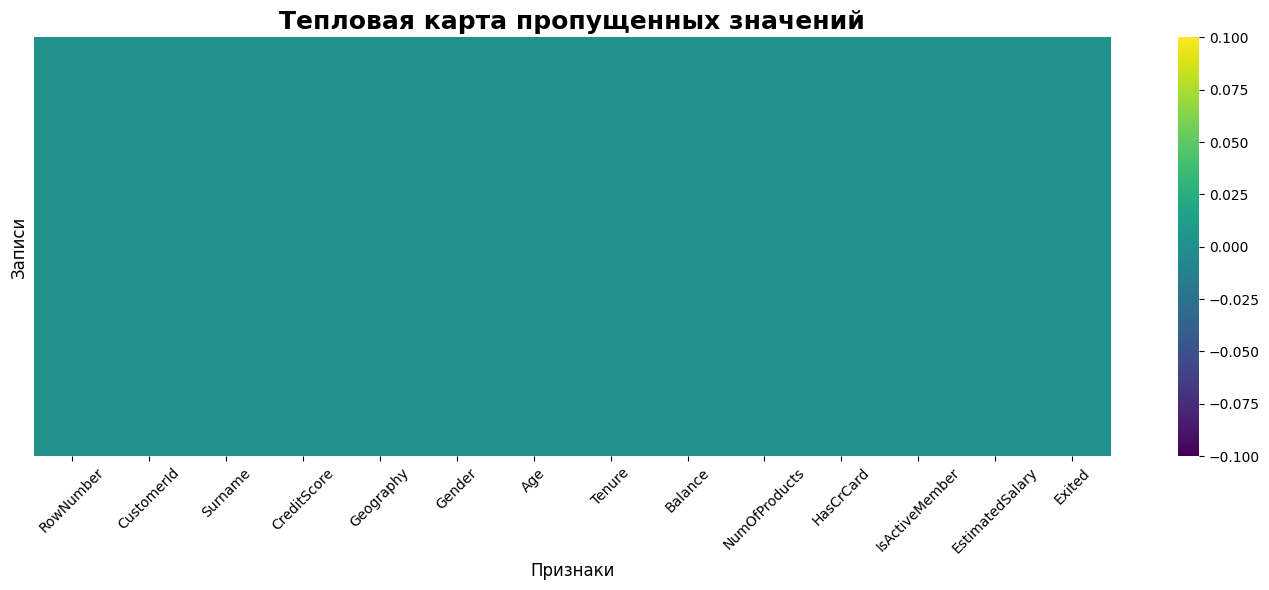

In [6]:
missing_values = df.isnull().sum()

print('Количество пропущенных значений:\n')
print(missing_values)

plt.figure(figsize=(14, 6))
sns.heatmap(
    df.isnull(),
    cmap='viridis',      
    cbar=True,           
    yticklabels=False    
)

plt.title(
    'Тепловая карта пропущенных значений',
    fontsize=18,
    fontweight='bold'
)

plt.xlabel('Признаки', fontsize=12)
plt.ylabel('Записи', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()


# ПРОВЕРКА ДУБЛИКАТОВ

In [7]:
duplicates = df.duplicated().sum()

print(f'Количество дубликатов: {duplicates}')

Количество дубликатов: 0


# ПРОВЕРКА БАЛАНСА КЛАССОВ

In [8]:
print('Распределение классов:\n')

print(df['Exited'].value_counts())

print('\nПроцентное распределение:\n')

print(df['Exited'].value_counts(normalize=True) * 100)

Распределение классов:

Exited
0    7963
1    2037
Name: count, dtype: int64

Процентное распределение:

Exited
0    79.63
1    20.37
Name: proportion, dtype: float64


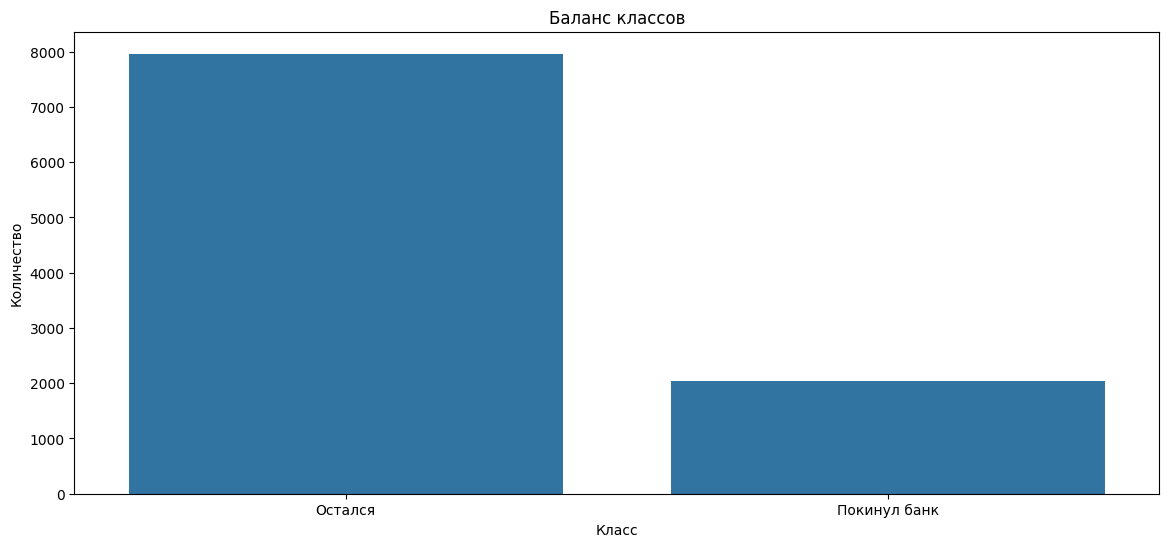

In [9]:
# Визуализация распределения классов

plt.figure(figsize=(14, 6))

sns.countplot(data=df, x='Exited')

plt.title('Баланс классов')

plt.xlabel('Класс')

plt.ylabel('Количество')

plt.xticks([0, 1], ['Остался', 'Покинул банк'])

plt.show()

# ОПИСАТЕЛЬНАЯ СТАТИСТИКА

In [10]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


# УДАЛЕНИЕ НЕНУЖНЫХ КОЛОНОК

In [11]:
columns_to_drop = [
    'RowNumber',
    'CustomerId',
    'Surname'
]


columns_to_drop = [
    col for col in columns_to_drop
    if col in df.columns
]


df = df.drop(columns=columns_to_drop)

print('Оставшиеся признаки:\n')

print(df.columns)

Оставшиеся признаки:

Index(['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance',
       'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
       'Exited'],
      dtype='str')


# ПОДГОТОВКА ДАННЫХ ДЛЯ ДАЛЬНЕЙШЕГО АНАЛИЗА

In [12]:
X = df.drop('Exited', axis=1)

y = df['Exited']

print('Размер X:', X.shape)

print('Размер y:', y.shape)

Размер X: (10000, 10)
Размер y: (10000,)


# ПРОВЕРКА КАТЕГОРИАЛЬНЫХ И ЧИСЛОВЫХ ПРИЗНАКОВ


In [13]:
categorical_columns = X.select_dtypes(include=['object']).columns

print('Категориальные признаки:\n')

print(categorical_columns)



numeric_columns = X.select_dtypes(include=['int64', 'float64']).columns

print('Числовые признаки:\n')

print(numeric_columns)

Категориальные признаки:

Index(['Geography', 'Gender'], dtype='str')
Числовые признаки:

Index(['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary'],
      dtype='str')


C:\Users\Maxam\AppData\Local\Temp\ipykernel_2424\257779779.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = X.select_dtypes(include=['object']).columns


# ИТОГ ЭТАПА ПОДГОТОВКИ ДАННЫХ

In [14]:
print("""
Этап подготовки данных завершен успешно.

Выполнено:
- датасет загружен;
- структура изучена;
- типы данных проверены;
- пропуски проверены;
- дубликаты проверены;
- баланс классов проверен;
- ненужные признаки удалены;
- данные подготовлены для EDA и обучения модели.
""")


Этап подготовки данных завершен успешно.

Выполнено:
- датасет загружен;
- структура изучена;
- типы данных проверены;
- пропуски проверены;
- дубликаты проверены;
- баланс классов проверен;
- ненужные признаки удалены;
- данные подготовлены для EDA и обучения модели.

